$$
\gdef \der#1#2{\frac{\partial #1}{\partial #2}}
\gdef \E{\mathbb E}
$$

# Intrinsic Plasticity

Assuming a Gaussian input distribution $f_x(x)$ and some function $y=g(x)$, by applying $f_y(y)=g(f_x(x))$ we obtain a transformed output distribution. We would like to maximize the information conveyed from $f_x(x)$ to $f_y(y)$ and we especially care about the gradient $\der{g}{x}$ to be large for as many $x$ as possible. If $g(x) = \frac{1}{1+e^{-x}}$ is taken to be sigmoidal the above is achieved by having it's midpoint be equal to the mean $\mu_x$ of $f_x$ and the slope correspond to the variance $\sigma_x$. 

In [73]:
%matplotlib inline 

from matplotlib.animation import FuncAnimation
from matplotlib import pyplot as plt
from numpy.random import normal
import numpy as np
# import jax.numpy as np

n = np.linspace(-10, 10)
plot_each = 200

class Function_IODist_Plotter:

    def __init__(self, func=None, x=None, dims=1):
        self.dims = dims
        self.fig, axes = plt.subplots(dims, 2, gridspec_kw={'width_ratios': [4, 1]}, sharey=True)
        self.axes_fun = [a[0] for a in axes] if dims>1 else [axes[0]]
        self.axes_hist = [a[1] for a in axes] if dims>1 else [axes[1]]
        for i in range(dims):
            self.axes_hist[i].get_yaxis().set_visible(False)
            if i < dims-1:
                self.axes_hist[i].get_xaxis().set_visible(False)
                self.axes_fun[i].get_xaxis().set_visible(False)
        # plt.tight_layout()
        if func is not None and x is not None:
            self.update_plot(func, x)

    def update_plot(self, func, inp):
        y_n = func(np.tile(n, (self.dims, n.ndim)).T)
        y_x = func(np.reshape(inp, (inp.shape[0], self.dims)))
        # print("inp shape", inp.shape)
        x_mean = inp.mean(axis=0).reshape((self.dims,))
        # print("x_mean shape", x_mean.shape)
        y_mean = func(x_mean)
        lower, upper = func(np.tile(-100,self.dims)), func(np.tile(100,self.dims))
        y_mins, y_maxs = -1.1*abs(lower), 1.1*abs(upper)
        for i in range(self.dims):
            y_min, y_max = y_mins[i], y_maxs[i]
            ax = self.axes_fun[i]
            ax.cla()
            if i == self.dims-1:
                #for j in range(self.dims):
                ax.hist(inp[:], density=True, bins=50, bottom=y_min)
            ax.plot(n, y_n[:,i], color='orange')
            # print("y_mean", y_mean.shape)
            ax.axvline(x_mean[i], color='k',
                                linestyle='dashed', linewidth=1)
            ax.axhline(y_mean[i], color='k',
                                linestyle='dashed', linewidth=1)
            ax.set_xlim(-10, 10)
            if y_min != y_max:
                ax.set_ylim([y_min, y_max])

            self.axes_hist[i].cla()
            self.axes_hist[i].hist(y_x[:,i], orientation='horizontal',
                        density=True, bins=50)
        
            self.axes_hist[i].axhline(y_mean[i], color='k',
                                linestyle='dashed', linewidth=1)


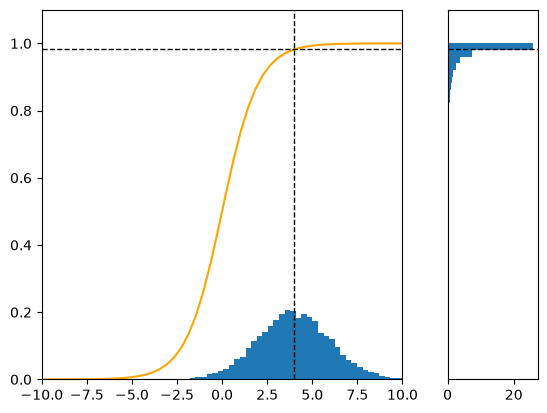

In [74]:
num_samples = 10000
mean_x = 4
std_x = 2


def sigmoid(x): return 1/(1+np.e**(-x))
def g(a, b): return lambda x: sigmoid(a*x + b)
x = normal(mean_x, std_x, num_samples)

Function_IODist_Plotter(g(1,0), x)

## Infomax
This is the aim of the "Infomax" update rule [@bell1995](http://dx.doi.org/10.1162%2Fneco.1995.7.6.1129) which maximizes the information retained after transforming in an online fashion. By introducing parameters $\alpha$ and $\beta$ and using them as $g(\alpha x+\beta)$ the following update rules will do the trick
$$
\alpha \leftarrow \alpha + \eta\left(\frac{1}{\alpha}+x(1-2y)\right)\\
\beta \leftarrow \beta + \eta\left(1-2y\right).
$$

In [42]:
def get_update_fun(learning_step, fun):

    def update_hist(step, params):
        new_x = normal(mean_x, std_x, plot_each)
        learning_step(params, new_x)
        a, b, x = params.values()
        my_plotter.update_plot(fun(a, b), x)
        plt.suptitle(f"{step*plot_each} samples")
    return update_hist

a:0.58   b:-1.82


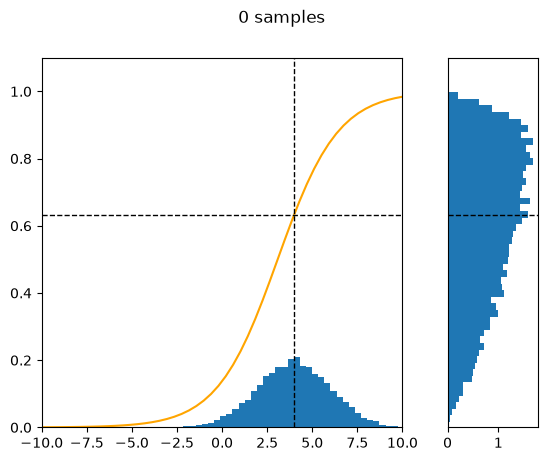

In [43]:

a, b = 1, 0

eta = 0.1

x = np.array([normal(mean_x, std_x)])

params = {'a': a, 'b': b, 'x': x}

my_plotter = Function_IODist_Plotter()
#my_plotter.update_plot(g(a,b), x)

def infomax_step(params, new_x):
    a, b, x = params.values()
    new_y = g(a, b)(new_x)
    params['a'] += eta * np.mean(1/a + new_x * (1-2*new_y))
    params['b'] += eta * np.mean(1-2*new_y)
    params['x'] = np.append(x, new_x)

#for step in range(num_samples):
#    new_x = normal(mean_x, std_x, plot_each)
#    infomax_step(params, new_x)
#a, b, x = params.values()
#my_plotter.update_plot(g(a,b), x)
anim = FuncAnimation(my_plotter.fig, get_update_fun(infomax_step, g), frames=num_samples//plot_each+1, fargs=(params,), interval=10, repeat=False)
anim.save("../plots/infomax.gif")
# plt.show()
print(f"a:{params['a']:.02f}   b:{params['b']:.02f}")

from IPython.display import HTML
HTML('<img src="../plots/infomax.gif">')


When using $\tanh$ as activation function the update rules become:

$$
a \leftarrow a + \eta \left(\frac{1}{a} - 2xy\right)\\
b \leftarrow b -  \eta 2y.
$$

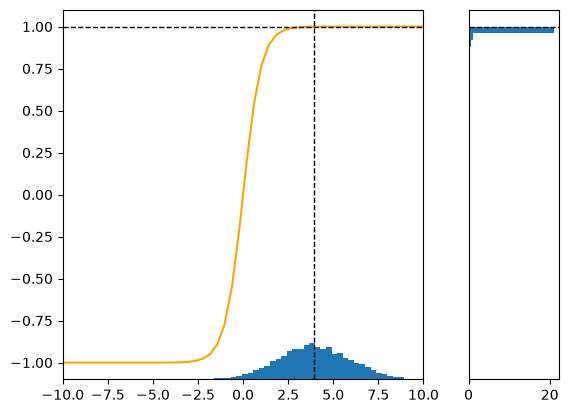

In [6]:
g_bar = lambda a,b: lambda x: np.tanh(a*x+b)

x=normal(mean_x, std_x, num_samples)

Function_IODist_Plotter().update_plot(g_bar(1,0), x)

inp shape (201,)
x_mean shape ()
x_mean 4.025150473299929
inp shape (401,)
x_mean shape ()
x_mean 4.074605183078416
inp shape (601,)
x_mean shape ()
x_mean 4.014316285160189
inp shape (801,)
x_mean shape ()
x_mean 4.094741979586443
inp shape (1001,)
x_mean shape ()
x_mean 4.068475565621927
inp shape (1201,)
x_mean shape ()
x_mean 4.057282371287007
inp shape (1401,)
x_mean shape ()
x_mean 4.040080251839336
inp shape (1601,)
x_mean shape ()
x_mean 4.0361804470307625
inp shape (1801,)
x_mean shape ()
x_mean 4.042709778359011
inp shape (2001,)
x_mean shape ()
x_mean 4.058593228148096
inp shape (2201,)
x_mean shape ()
x_mean 4.048684248460994
inp shape (2401,)
x_mean shape ()
x_mean 4.0421403324184455
inp shape (2601,)
x_mean shape ()
x_mean 4.027053655326713
inp shape (2801,)
x_mean shape ()
x_mean 4.02592811506326
inp shape (3001,)
x_mean shape ()
x_mean 4.039692861713511
inp shape (3201,)
x_mean shape ()
x_mean 4.034541955681846
inp shape (3401,)
x_mean shape ()
x_mean 4.034964665469824


inp shape (10601,)
x_mean shape ()
x_mean 3.980884614994499


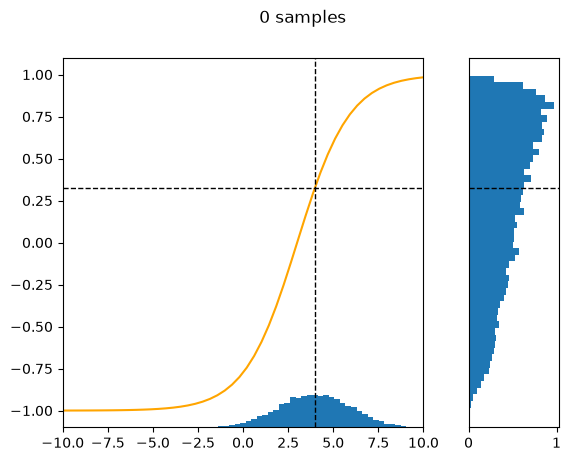

In [34]:
eta=0.03
params = {'a': 1, 'b': 0, 'x': np.array([normal(mean_x, std_x)])}

# @jax.jit
def infomax_step_tanh(params, new_x):
    a,b,x = params.values()
    new_y = g_bar(a,b)(new_x)
    params['a'] += eta*np.mean(1/a-2*new_x*new_y)
    params['b'] -= eta*np.mean(2*new_y)#4*eta*np.mean(new_x*new_y**2)
    params['x'] = np.append(x, new_x)

#for step in range(num_samples//plot_each):
#    infomax_step_tanh(params)

my_plotter = Function_IODist_Plotter()
anim = FuncAnimation(my_plotter.fig, get_update_fun(infomax_step_tanh, g_bar), frames=num_samples//plot_each+1, fargs=(params,), interval=10, repeat=False)
#anim.save("test.mp4")
anim.save("../plots/infomax_tanh.gif")
# plt.show()
print(f"a:{params['a']:.02f}   b:{params['b']:.02f}")

from IPython.display import HTML
HTML('<img src="../plots/infomax_tanh.gif">')

## N -> N network

/var/folders/35/1sw23spn5lj8fry0yqpg7ygr0000gn/T/ipykernel_9272/2403685593.py:6: RuntimeWarning: overflow encountered in power
  def sigmoid(x): return 1/(1+np.e**(-x))


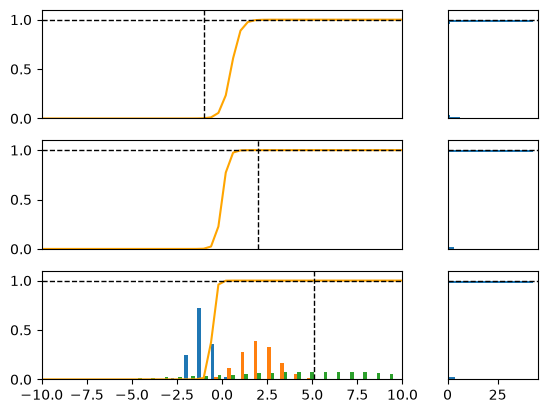

In [56]:
N=3

means = -1, 2, 5
stds = 0.5, 1, 5

A = np.array([[1,2,3], [1,2,2], [2,2,4]])
b = np.array([-2,0,5])

def g_mat(A, b): return lambda x: sigmoid(x@A + b)

x = normal(means, stds, (num_samples, N))
# print(x.shape)
y=g_mat(A,b)(x)

Function_IODist_Plotter(g_mat(A,b), x, dims=N)

## IP rule [@shaw2020]

(10000,)


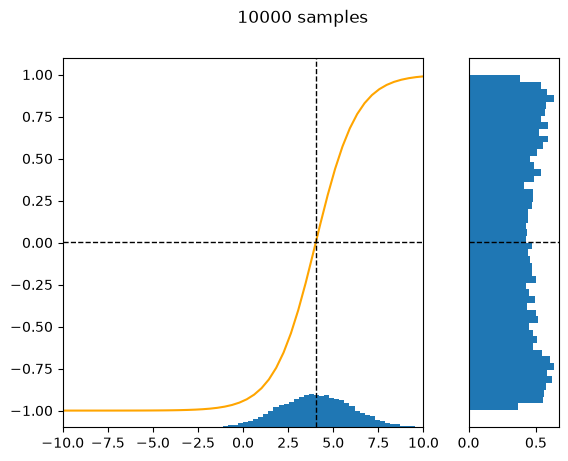

a:2.28   b:4.03


In [77]:

def g_shaw(a, b): return lambda x: np.tanh((x-b)/a)


x = normal(mean_x, std_x, num_samples)
print(x.shape)

eta = 0.1
params = {'a': 1, 'b': 0, 'x': np.array([normal(mean_x, std_x)])}


def infomax_step_shaw(params, new_x):
        a, b, x = params.values()
        new_y = g_shaw(a, b)(new_x)
        params['a'] += eta*(-params['a'] + 2*np.mean(new_x*new_y))
        params['b'] += eta*4*np.mean(new_x*new_y)*np.mean(new_y)
        if True:  # Actual gradients when deriving dH/da
            params['a'] += eta*(-1/params['a'] + 2 *
                                np.mean(new_x*new_y)/(params['a']**2))
            params['b'] += eta*2*np.mean(new_y)/params['a']
        params['x'] = np.append(x, new_x)

# for step in range(num_samples//plot_each):
#    infomax_step_tanh(params)

my_plotter = Function_IODist_Plotter()
anim = FuncAnimation(my_plotter.fig, get_update_fun(infomax_step_shaw, g_shaw),
                        frames=num_samples//plot_each+1, fargs=(params,), interval=10, repeat=False)
anim.save("../plots/intrinsic_plasticity.gif")
plt.show()


# p = Process(target=_anim)
# p.start()
# p.join()
print(f"a:{params['a']:.02f}   b:{params['b']:.02f}")

HTML('<img src="../plots/intrinsic_plasticity.gif">')
